In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../Dataset/final.csv')
df.head()

,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ecg_peak_freq,resp_peak_freq,temp_slope,eda_slope,label,subject
0,0.872800,0.024465,0.5070,1.1758,-0.132889,0.031347,-0.4014,0.1010,-0.284486,0.047498,...,0.929273,0.025727,0.522995,1.506039,2.200000,0.433333,-0.000012,-0.000033,0,2
1,0.875788,0.059040,0.4826,1.2712,-0.120982,0.078589,-0.4616,0.1268,-0.245599,0.127737,...,0.929947,0.056012,0.496726,1.303793,2.600000,0.066667,-0.000037,-0.000015,0,2
2,0.861583,0.021205,0.7454,1.1624,-0.156330,0.020616,-0.2042,-0.1002,-0.316530,0.031280,...,0.931918,0.018373,0.785213,1.185841,1.300000,0.100000,0.000004,0.000032,0,2
3,0.862690,0.009803,0.7906,0.9224,-0.181321,0.022755,-0.2394,-0.1370,-0.306185,0.014533,...,0.933610,0.007607,0.882272,0.981359,2.466667,0.366667,0.000003,-0.000026,0,2
4,0.857272,0.006321,0.8050,0.9246,-0.188318,0.022537,-0.2520,-0.1382,-0.320673,0.011200,...,0.934800,0.005797,0.882175,0.996625,1.200000,0.400000,-0.000011,-0.000036,0,2


In [3]:
df.columns

Index(['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_y_mean',
       'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_z_mean', 'acc_z_std',
       'acc_z_min', 'acc_z_max', 'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max',
       'emg_mean', 'emg_std', 'emg_min', 'emg_max', 'eda_mean', 'eda_std',
       'eda_min', 'eda_max', 'temp_mean', 'temp_std', 'temp_min', 'temp_max',
       'resp_mean', 'resp_std', 'resp_min', 'resp_max', 'net_acc_mean',
       'net_acc_std', 'net_acc_min', 'net_acc_max', 'ecg_peak_freq',
       'resp_peak_freq', 'temp_slope', 'eda_slope', 'label', 'subject'],
      dtype='str')

In [4]:
df.drop(columns=['subject'], inplace=True)

In [5]:
df.shape

(2839, 41)

In [49]:
count = 0
for numCount in df.isnull().sum():
    if(numCount > 0):
        count += 1
print("Number of columns with null values: " + str(count))

Number of columns with null values: 0


In [7]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["label"].value_counts()

label
0    1310
1     581
4     387
2     326
3     180
7      19
6      18
5      18
Name: count, dtype: int64

In [5]:
accept_label = [1, 2, 3, 4]
df = df[df["label"].isin(accept_label)]
df["label"].value_counts()

label
1    581
4    387
2    326
3    180
Name: count, dtype: int64

In [6]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["label"] = df["label"].apply(apply_target)

In [33]:
df["label"].value_counts()

label
0    1148
1     326
Name: count, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
x_train = train.drop("label", axis=1)
y_train = train["label"]

y_test = test["label"]
x_test = test.drop("label", axis=1)

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_res, y_res = smote.fit_resample(x_train, y_train)

In [10]:
y_res.value_counts()

label
0    925
1    925
Name: count, dtype: int64

In [11]:
from xgboost import XGBClassifier, plot_importance, plot_tree

model = XGBClassifier(
    n_estimators      = 100,       # number of boosting rounds
    max_depth         = 3,         # depth of each tree
    learning_rate     = 0.2,       # shrinks contribution of each tree (eta)
    subsample         = 0.7,       # fraction of samples per tree
    colsample_bytree  = 0.7,       # fraction of features per tree
    gamma             = 0,         # min loss reduction to split a node
    reg_alpha         = 0,         # L1 regularization
    reg_lambda        = 1,         # L2 regularization
    eval_metric       = "logloss",  # "logloss" for binary
    objective        = "binary:logistic",  # ← add this for binary (0/1)
    random_state      = 42,
    n_jobs            = -1
)



model.fit(
    X_res, y_res,
    eval_set              = [(X_res, y_res), (x_test, y_test)],
    verbose               = 10        # print every 10 rounds
)

[0]	validation_0-logloss:0.56028	validation_1-logloss:0.57082
[10]	validation_0-logloss:0.17225	validation_1-logloss:0.23068
[20]	validation_0-logloss:0.08422	validation_1-logloss:0.16197
[30]	validation_0-logloss:0.04454	validation_1-logloss:0.11642
[40]	validation_0-logloss:0.02610	validation_1-logloss:0.09742
[50]	validation_0-logloss:0.01779	validation_1-logloss:0.08860
[60]	validation_0-logloss:0.01217	validation_1-logloss:0.08315
[70]	validation_0-logloss:0.00908	validation_1-logloss:0.08053
[80]	validation_0-logloss:0.00723	validation_1-logloss:0.07954
[90]	validation_0-logloss:0.00586	validation_1-logloss:0.07873
[99]	validation_0-logloss:0.00510	validation_1-logloss:0.07718


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# y_test = test["label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9694915254237289
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       223
           1       0.90      0.99      0.94        72

    accuracy                           0.97       295
   macro avg       0.95      0.98      0.96       295
weighted avg       0.97      0.97      0.97       295



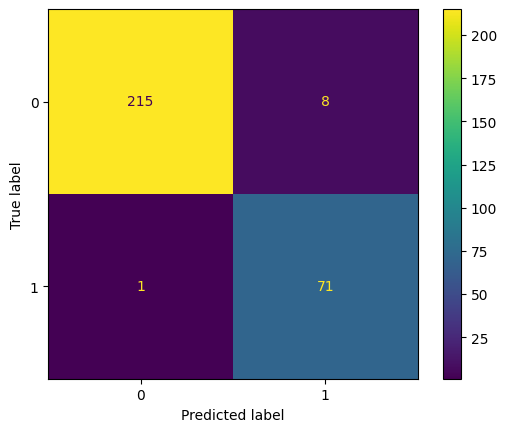

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
# cm = confusion_matrix(y_test_res, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [23]:
x_test_res, y_test_res = smote.fit_resample(x_test, y_test)

In [24]:
y_pred = model.predict(x_test_res)

In [25]:

print("Accuracy:", accuracy_score(y_test_res, y_pred))
print(classification_report(y_test_res, y_pred))

Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       223
           1       0.97      0.99      0.98       223

    accuracy                           0.98       446
   macro avg       0.98      0.98      0.98       446
weighted avg       0.98      0.98      0.98       446



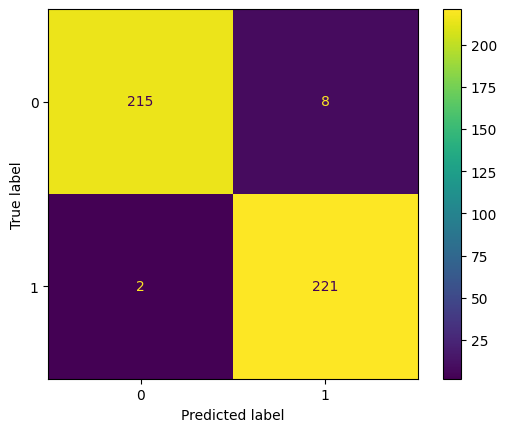

In [26]:
cm = confusion_matrix(y_test_res, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

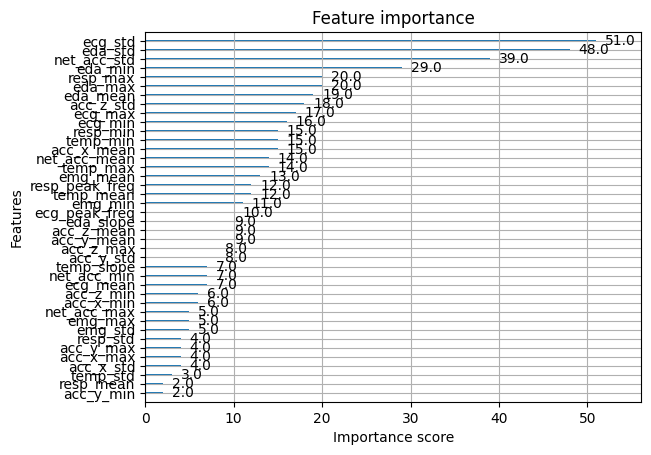

In [27]:
from xgboost import plot_importance
plot_importance(model)

In [28]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=train.drop("label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [29]:
explanation = explainer.explain_instance(
    data_row=x_test.iloc[0].values,   # <-- FIX
    predict_fn=model.predict_proba,
    num_features=100
)

In [35]:
x_test.iloc[0]

acc_x_mean        7.013757e-01
acc_x_std         4.968986e-03
acc_x_min         6.844000e-01
acc_x_max         7.210000e-01
acc_y_mean        1.536841e-02
acc_y_std         3.330526e-03
acc_y_min         2.400041e-03
acc_y_max         3.260005e-02
acc_z_mean       -6.268743e-01
acc_z_std         6.292726e-03
acc_z_min        -6.498000e-01
acc_z_max        -5.970000e-01
ecg_mean          9.557778e-04
ecg_std           1.190023e-01
ecg_min          -5.220795e-01
ecg_max           7.875366e-01
emg_mean         -2.543333e-03
emg_std           8.157559e-03
emg_min          -4.783630e-02
emg_max           2.522278e-02
eda_mean          9.314177e-01
eda_std           1.326602e-02
eda_min           8.464813e-01
eda_max           1.081848e+00
temp_mean         3.437058e+01
temp_std          2.736233e-02
temp_min          3.428326e+01
temp_max          3.450207e+01
resp_mean        -5.389818e-02
resp_std          2.638791e+00
resp_min         -7.942200e+00
resp_max          5.735779e+00
net_acc_

In [32]:
y_test.iloc[0]

np.int64(0)

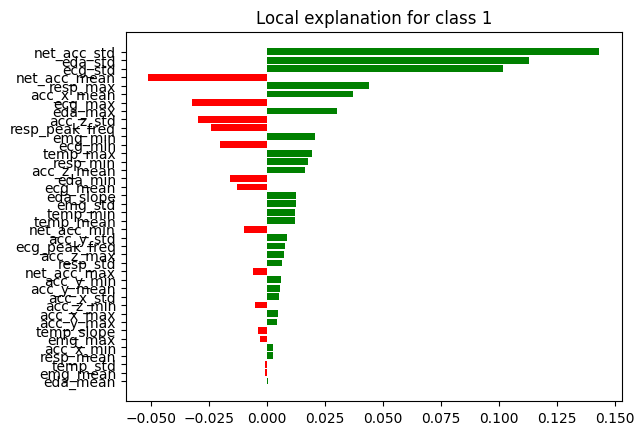

In [33]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

In [45]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test_res)

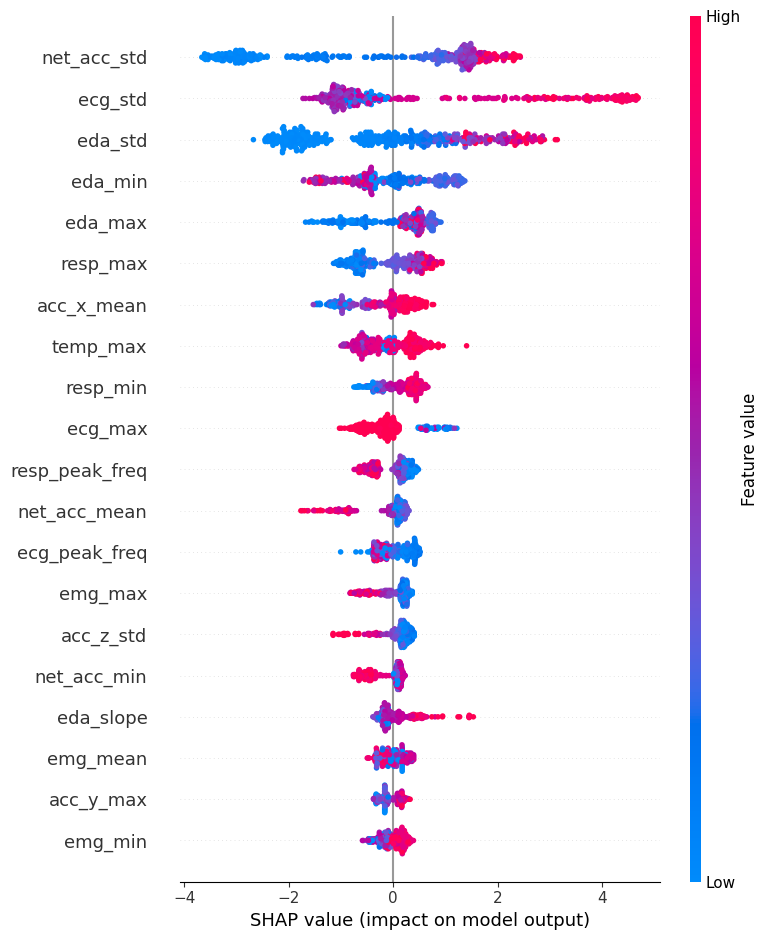

In [46]:
shap.summary_plot(shap_values, x_test_res)

In [46]:
import dice_ml
from dice_ml import Dice

dice_data = dice_ml.Data(dataframe=df,
                         # For perturbation strategy
                         continuous_features=df.drop("label", axis=1).columns.tolist(),
                         outcome_name='label')

In [47]:
dice_model = dice_ml.Model(
    model=model,
    backend="sklearn"   # works for XGBoost sklearn API
)

In [48]:

dice = Dice(dice_data, dice_model)

In [49]:
x = x_test.iloc[[0]]   # ✅ double brackets → keeps it as DataFrame

In [53]:
cf = dice.generate_counterfactuals(
    x,
    total_CFs=10,                # only one CF
    desired_class="opposite"    # flip prediction
)

100%|██████████| 1/1 [00:00<00:00,  1.13it/s]


In [54]:
cf.visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 0)


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,resp_max,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ecg_peak_freq,resp_peak_freq,temp_slope,eda_slope,label
0,0.701376,0.004969,0.6844,0.721,0.015368,0.003331,0.0024,0.0326,-0.626874,0.006293,...,5.735779,0.940851,0.0033,0.925576,0.953128,1.233333,0.3,6.632702e-07,9.512557e-08,0



Diverse Counterfactual set (new outcome: 1)


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,resp_max,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ecg_peak_freq,resp_peak_freq,temp_slope,eda_slope,label
0,0.67636033,-,-,-,-,-,-,-,-,-,...,-,-,0.4699524451,-,-,-,-,6.632701691282649e-07,9.512557041099765e-08,1.0
1,-,-,-,-,-,-,-,-,-,-,...,10.865835,-,0.1022729634,0.71814081,-,-,-,6.632701691282649e-07,9.512557041099765e-08,1.0
2,0.8599567,-,-,-,-0.26450167334,-,-,-,-,-,...,-,-,0.2219222822,-,-,8.6,-,6.632701691282649e-07,9.739227e-06,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-,-,0.3253919795,-,-,20.0,0.10129605,6.632701691282649e-07,9.512557041099765e-08,1.0
4,-,-,-,-,-,-,-,-,-,-,...,-,-,0.0220632896,-,-,-,-,6.632701691282649e-07,9.512557041099765e-08,1.0
5,-,-,-,-,-,-,-,-,-,-,...,-,-,0.4545725773,-,-,-,0.25747192,6.632701691282649e-07,9.512557041099765e-08,1.0
6,0.67636033,-,-,-,-,-,-,-,-,-,...,-,-,0.4699524451,-,-,-,-,6.632701691282649e-07,9.512557041099765e-08,1.0
7,-,-,-,-,-,-,-,-,-,-,...,-,-,0.0220632896,-,-,-,-,6.632701691282649e-07,9.512557041099765e-08,1.0
8,-,-,-,-,-,-,-,-,-,-,...,-,-,0.2949325301,-,-,-,-,9.0995235e-05,9.512557041099765e-08,1.0
9,-,-,-,-,-,-,-,-,-,-,...,-,-,0.0220632896,-,-,-,-,6.632701691282649e-07,9.512557041099765e-08,1.0
